# N2 vs N3 Infraslow Analysis Demo (Delta / Slow-Wave)

Downstream analysis/visualization notebook over `infraslow.pipeline`'s already-computed
per-subject ISFS spectrum and phase features (see `src/scripts/preprocessing.py` for how
the underlying `.npz`/`.csv` artifacts under `/scratch/users/chaisaen/processed_data/data/`
were generated). No EEG filtering, spindle/slow-wave detection, or envelope computation
happens here -- every number below comes from `infraslow.pipeline.pipeline.run_subject_state_channel`
and `infraslow.stat.state_comparison`, reused unmodified from the rest of the project.

This is the **delta-band / slow-wave** analog of `demo_plot_and_compared.ipynb`: instead of
sigma-band spindles phase-locked to the infraslow (ISFS) oscillation, it looks at delta-band
slow waves. `run_subject_state_channel(..., event="sw")` pairs delta-band ISFS spectra with
`sw_bouts.npz["sw"]`/`sw_yasa.csv["NegPeak"]` events instead of sigma/`bouts.npz["spindle"]`/
`spindel_yasa.csv["Peak"]` -- everything downstream (feature names, phase-bin machinery,
statistics) is otherwise identical to the sigma notebook.

Compares **N2 vs N3** on channel **C3** across every eligible subject (sorted by id) with
usable slow-wave-containing bouts in both states, or the first `N_SUBJECTS` if that's set to
a number instead of `None`.

## 1. Imports and Configuration

In [19]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from infraslow.pipeline import pipeline as ppl
from infraslow.pipeline import phase as pph
from infraslow.processing.infraslow import (
    DEFAULT_INFRASLOW_BAND,
    DEFAULT_BASELINE_BAND,
    bigaussian,
    fit_isfs,
)
from infraslow.stat import state_comparison as stc

# infraslow.pipeline.pipeline transitively imports infraslow.pipeline.figures, which
# calls matplotlib.use("Agg") at import time (a headless-safe default for the batch
# pipeline) -- that forces a non-interactive backend, silently overriding an earlier
# `%matplotlib inline`. Issuing the magic here, after those imports, re-enables inline
# figure display in this notebook without touching the pre-existing pipeline module.
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'
ORANGE, LORANGE = '#d2691e', '#f2c14e'
COLORS = {"N2": (PURPLE, LPURPLE), "N3": (ORANGE, LORANGE)}

DATA_DIR = Path("/scratch/users/chaisaen/processed_data/data")
CHANNEL = "C3"
STATES = ("N2", "N3")
# "sw" selects the delta/slow-wave pathway in run_subject_state_channel (band="delta",
# paired against sw_bouts.npz["sw"]/sw_yasa.csv["NegPeak"]) instead of the default
# "spindle" pathway (band="sigma", bouts.npz["spindle"]/spindel_yasa.csv["Peak"]).
EVENT = "sw"
# DATA_DIR holds 169,740 subject directories -- None (scan/use everything) is not
# practical here (each candidate costs several file reads + a curve_fit; the full-cohort
# batch run took 8+ hours to process its first ~30 subjects). N_SUBJECTS caps how many
# *usable* subjects to keep; CANDIDATE_LIMIT (next cell) caps how many candidates get
# scanned to find them -- set N_SUBJECTS to an int for interactive/notebook use.
N_SUBJECTS = 9000

## 2. Find Eligible Subjects

Sorted by id (`infraslow.pipeline.io.discover_subjects`'s own order, preserved by
`run_subject_state_channel`'s scan below). A non-`None` **spectrum** record for every state
in `STATES` is not sufficient on its own -- `infraslow.pipeline.spectrum`'s
`_nan_spectrum_features` fallback can return a non-`None` record whose spectrum fields
(`peak_freq_hz`, `curves["rel"]`, `curves["corrected"]`, etc.) are all NaN when zero ISFS
rows match. Separately (and by design, see its docstring),
`infraslow.pipeline.phase.compute_subject_phase_features` excludes a subject/state with
fewer than `DEFAULT_ISFS_MIN_EVENTS` in-cycle slow-wave events from phase reporting --
`phase_bin_rates=None` in that case -- independent of whether its spectrum was computable.
A subtler case: a subject/state can have >=5 *total* detected slow-wave events but zero
*in-cycle* ISFS events, in which case `phase_bin_rates` is `[0.0]*8` (NOT `None`) and
`mean_phase` is NaN -- that would silently pass a `phase_bin_rates is not None` check
alone. Section 5 (phase analysis) needs real, finite phase data on every selected
subject/state, and Section 7's circular supplement needs a finite `mean_phase` for every
subject in both states to keep the N2/N3 pairing intact -- so we scan the cohort and filter
down to every subject (still sorted by id, capped at `N_SUBJECTS` if that's set) that has a
finite spectrum AND non-degenerate, finite phase data in every state.

In [ ]:
def _is_usable(entry):
    # A non-None spectrum record from run_subject_state_channel is not sufficient on its
    # own: it can still return an all-NaN spectrum record (zero ISFS rows matched --
    # infraslow.pipeline.spectrum._nan_spectrum_features), or a record with all-zero
    # phase_bin_rates and NaN mean_phase (zero in-cycle-ISFS events despite >= 5 total
    # detected slow waves -- phase_bin_rates is [0.0]*8, NOT None, in that case, so it
    # would silently pass a phase_bin_rates-is-not-None-only check). Require a finite
    # spectrum plus finite, non-degenerate phase data in every state.
    for state in STATES:
        record = entry[state][0]
        phase_bin_rates = record.get("phase_bin_rates")
        if phase_bin_rates is None:
            return False
        if not np.isfinite(record["peak_freq_hz"]):
            return False
        if sum(phase_bin_rates) <= 0:
            return False
        if not np.isfinite(record["mean_phase"]):
            return False
    return True


# CANDIDATE_LIMIT bounds how many subjects get scanned in total. When N_SUBJECTS is set,
# the loop below stops as soon as N_SUBJECTS *usable* subjects are found (not a fixed
# margin scanned up front) -- so CANDIDATE_LIMIT=None ("no cap") stays fast for a small
# N_SUBJECTS: it only scans as far into the (sorted-by-id, 169,740-subject) cohort as it
# actually needs to. CANDIDATE_LIMIT only matters as a safety cap when N_SUBJECTS is also
# None (nothing to stop early on -- that combination does mean "scan everything"), or if
# usable subjects turn out to be rarer than expected and you want to bound runtime anyway.
CANDIDATE_LIMIT = None
verbose = True  # print live scan progress (one line per subject scanned)

candidates = {}
n_usable = 0
n_scanned = 0
for subject_id in ppl.pio.discover_subjects(DATA_DIR):
    if CANDIDATE_LIMIT is not None and len(candidates) >= CANDIDATE_LIMIT:
        break
    n_scanned += 1
    per_state = {}
    for state in STATES:
        record, bout_records, _failure, curves = ppl.run_subject_state_channel(
            DATA_DIR, subject_id, CHANNEL, state, event=EVENT, return_curves=True,
        )
        if record is None:
            break
        per_state[state] = (record, bout_records, curves)
    if len(per_state) != len(STATES):
        if verbose:
            print(f"[{n_scanned}] {subject_id}: not paired (missing/failed a state) "
                  f"-- {len(candidates)} paired, {n_usable} usable so far")
        continue
    candidates[subject_id] = per_state
    usable = _is_usable(per_state)
    if usable:
        n_usable += 1
    if verbose:
        target = f"/{N_SUBJECTS}" if N_SUBJECTS is not None else ""
        print(f"[{n_scanned}] {subject_id}: paired, {'usable' if usable else 'not usable'} "
              f"-- {len(candidates)} paired, {n_usable}{target} usable so far")
    if usable and N_SUBJECTS is not None and n_usable >= N_SUBJECTS:
        break

phase_complete = {sid: data for sid, data in candidates.items() if _is_usable(data)}
# Slicing a list with [:None] returns the whole list, so this keeps every usable
# subject when N_SUBJECTS is None and caps at N_SUBJECTS (first N by id) otherwise.
paired_data = dict(list(phase_complete.items())[:N_SUBJECTS])
SUBJECT_IDS = list(paired_data)
# if N_SUBJECTS is not None:
#     assert len(SUBJECT_IDS) == N_SUBJECTS, (
#         f"expected {N_SUBJECTS} paired subjects with usable, finite spectrum AND phase data, "
#         f"found {len(SUBJECT_IDS)} among {len(candidates)} spectrum-paired candidates scanned "
#         f"(exhausted the cohort before finding enough -- try raising CANDIDATE_LIMIT if it "
#         f"wasn't already None, or there may not be enough usable subjects available)"
#     )

print(f"Selected {len(SUBJECT_IDS)} subjects with usable, finite {'/'.join(STATES)} spectrum + "
      f"phase data on {CHANNEL} (out of {len(candidates)} spectrum-paired candidates scanned):")
for sid in SUBJECT_IDS:
    print(f"  {sid}")

Selected 2319 subjects with usable, finite N2/N3 spectrum + phase data on C3 (out of 2449 spectrum-paired candidates scanned):
  317947
  318517
  318562
  318619
  318658
  318661
  318667
  318668
  318709
  318728
  318732
  318743
  318763
  318766
  318768
  318769
  318775
  318778
  318783
  318819
  318825
  318826
  318843
  318848
  318865
  318868
  318871
  318873
  318877
  318878
  318880
  318888
  318894
  318899
  318907
  318910
  318912
  318913
  318917
  318918
  318919
  318921
  318927
  318932
  319018
  319020
  319021
  319026
  319029
  319030
  319032
  319033
  319036
  319037
  319040
  319042
  319043
  319045
  319046
  319048
  319053
  319055
  319056
  319057
  319059
  319061
  319062
  319065
  319066
  319067
  319068
  319069
  319072
  319076
  319078
  319079
  319082
  319087
  319095
  319096
  319098
  319102
  319103
  319113
  319114
  319115
  319117
  319118
  319122
  319134
  319135
  319138
  319140
  319141
  319142
  319143
  319148


## 3. Load Subject Data

`paired_data` (from Section 2) already holds every `(record, bout_records, curves)` this
notebook needs -- no further disk I/O happens below. This section validates the expected
keys/shapes are present and assembles the two tidy per-state feature tables
(`n2_df`/`n3_df`) the rest of the notebook uses.

In [24]:
REQUIRED_RECORD_KEYS = {
    "subject_id", "sleep_state", "peak_freq_hz", "peak_period_s", "bandwidth_hz", "auc",
    "chromatogram_peak_area", "bi_gaussian_amp", "bi_gaussian_mu", "bi_gaussian_sd_l",
    "bi_gaussian_sd_r", "phase_bin_rates", "mean_phase", "resultant_length",
}
for sid in SUBJECT_IDS:
    for state in STATES:
        record, _bout_records, curves = paired_data[sid][state]
        missing = REQUIRED_RECORD_KEYS - record.keys()
        assert not missing, f"{sid}/{state} missing keys: {missing}"
        assert curves["freqs"].shape == curves["rel"].shape == curves["corrected"].shape
        assert np.isfinite(curves["rel"]).all(), f"{sid}/{state}: non-finite curves['rel']"
        assert np.isfinite(curves["corrected"]).all(), f"{sid}/{state}: non-finite curves['corrected']"
        assert len(record["phase_bin_rates"]) == 8

n2_df = pd.DataFrame([paired_data[sid]["N2"][0] for sid in SUBJECT_IDS])
n3_df = pd.DataFrame([paired_data[sid]["N3"][0] for sid in SUBJECT_IDS])
print(f"n2_df: {n2_df.shape}, n3_df: {n3_df.shape}")
print("All subject/state records contain the expected ISFS spectrum and phase keys, "
      "and all curves are finite.")

n2_df: (2319, 35), n3_df: (2319, 35)
All subject/state records contain the expected ISFS spectrum and phase keys, and all curves are finite.


## 4. N2 vs N3 ISFS Spectral Analysis (Delta Band)

### 4.1 Subject-Level Spectra

In [25]:
# The frequency grid is fixed by preprocessing.py's WINDOW_SEC (not per-bout length),
# so every subject/state shares the same `freqs` -- verify that before stacking.
freqs = paired_data[SUBJECT_IDS[0]]["N2"][2]["freqs"]
for sid in SUBJECT_IDS:
    for state in STATES:
        assert np.allclose(paired_data[sid][state][2]["freqs"], freqs)

rel_by_state = {
    state: np.stack([paired_data[sid][state][2]["rel"] for sid in SUBJECT_IDS])
    for state in STATES
}
corrected_by_state = {
    state: np.stack([paired_data[sid][state][2]["corrected"] for sid in SUBJECT_IDS])
    for state in STATES
}
band_m = (freqs >= DEFAULT_INFRASLOW_BAND[0]) & (freqs <= DEFAULT_INFRASLOW_BAND[1])
{state: rel_by_state[state].shape for state in STATES}

{'N2': (2319, 40), 'N3': (2319, 40)}

### 4.2 Average Relative Spectral Power

In [26]:
# Subject-level average (not pooled): mean +/- SEM across subjects' own
# per-subject relative-power curves -- infraslow.stat.state_comparison.mean_sem.
rel_mean = {state: stc.mean_sem(rel_by_state[state]) for state in STATES}

### 4.3 Baseline Correction

Baseline correction (subtracting the mean power over `DEFAULT_BASELINE_BAND`) was already
applied per-subject/state by `infraslow.pipeline.spectrum.compute_subject_spectrum_features`
(via `infraslow.processing.infraslow.baseline_correct`) when Section 2's scan built
`paired_data` -- `corrected_by_state` (below) is that result, not recomputed.

In [27]:
corrected_mean = {state: stc.mean_sem(corrected_by_state[state]) for state in STATES}

### 4.4 Bi-Gaussian Fits

Each subject's own bi-Gaussian fit parameters are already in `n2_df`/`n3_df`
(`bi_gaussian_*`, `peak_freq_hz`, `bandwidth_hz`, `auc`, `chromatogram_peak_area` -- see
Section 6/7). For the group-comparison figure below, `fit_isfs` (unmodified, the same
function `infraslow.pipeline.spectrum.compute_subject_spectrum_features` calls per subject)
is applied once more directly to each state's **group-average** baseline-corrected
spectrum, giving one representative bi-Gaussian curve per state to overlay.

In [28]:
group_fit = {}
for state in STATES:
    mean_corrected = corrected_mean[state][0]
    group_fit[state] = fit_isfs(
        freqs, mean_corrected, infraslow_band=DEFAULT_INFRASLOW_BAND, baseline_band=DEFAULT_BASELINE_BAND,
    )
    fit = group_fit[state]
    print(f"{state} group fit: peak={fit['mu']:.4f} Hz (~{1/fit['mu']:.0f} s) | "
          f"bandwidth={fit['bandwidth']:.4f} Hz | detected={fit['detected']}")

N2 group fit: peak=0.0225 Hz (~44 s) | bandwidth=0.0384 Hz | detected=True
N3 group fit: peak=0.0250 Hz (~40 s) | bandwidth=0.0389 Hz | detected=True


#### Figure: N2 vs N3 average ISFS spectrum (delta band, slow-wave-paired)

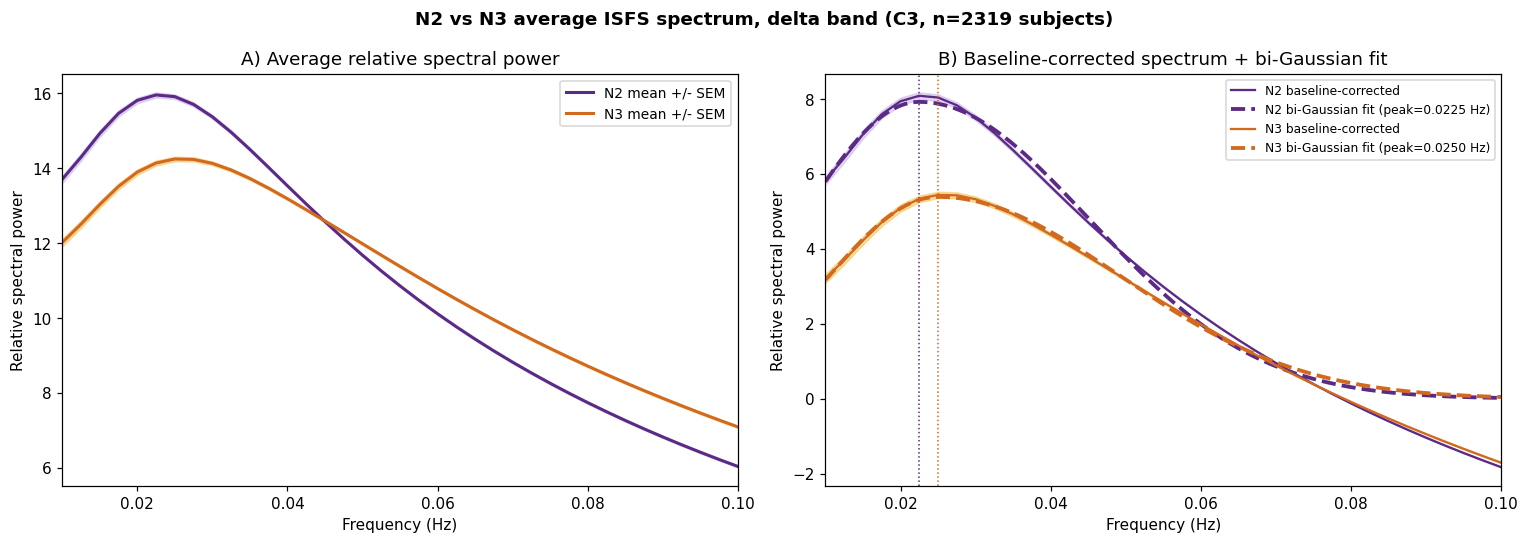

In [29]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

for state in STATES:
    dark, light = COLORS[state]
    mean_rel, sem_rel = rel_mean[state]
    axL.fill_between(freqs[band_m], (mean_rel - sem_rel)[band_m], (mean_rel + sem_rel)[band_m],
                      color=light, alpha=0.5)
    axL.plot(freqs[band_m], mean_rel[band_m], color=dark, lw=2, label=f"{state} mean +/- SEM")
axL.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
        title="A) Average relative spectral power")
axL.legend(frameon=True, fontsize=9)

fg = np.linspace(*DEFAULT_INFRASLOW_BAND, 400)
for state in STATES:
    dark, light = COLORS[state]
    mean_corr, sem_corr = corrected_mean[state]
    fit = group_fit[state]
    axR.fill_between(freqs[band_m], (mean_corr - sem_corr)[band_m], (mean_corr + sem_corr)[band_m],
                      color=light, alpha=0.5)
    axR.plot(freqs[band_m], mean_corr[band_m], color=dark, lw=1.5, label=f"{state} baseline-corrected")
    axR.plot(fg, bigaussian(fg, *fit["popt"]), color=dark, lw=2.5, ls="--",
              label=f"{state} bi-Gaussian fit (peak={fit['mu']:.4f} Hz)")
    axR.axvline(fit["mu"], color=dark, lw=1, ls=":")
axR.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
        title="B) Baseline-corrected spectrum + bi-Gaussian fit")
axR.legend(frameon=True, fontsize=8)

fig.suptitle(f"N2 vs N3 average ISFS spectrum, delta band ({CHANNEL}, n={len(SUBJECT_IDS)} subjects)",
             fontweight="bold")
fig.tight_layout()

## 5. N2 vs N3 Slow-Wave Phase Analysis

### 5.1 Subject-Level Phase Distributions

Each subject/state's 8-bin `phase_bin_rates` (already computed by
`infraslow.pipeline.phase.compute_subject_phase_features` inside Section 2's scan) is
stacked into `(n_subjects, 8)` arrays; `bin_center_angle` (unmodified, from
`infraslow.pipeline.phase`) gives each bin's phase angle for the x-axis below.

In [30]:
phase_rates = {
    state: np.stack([paired_data[sid][state][0]["phase_bin_rates"] for sid in SUBJECT_IDS])
    for state in STATES
}
bin_centers = pph.bin_center_angle(np.arange(1, 9))
{state: phase_rates[state].shape for state in STATES}

{'N2': (2319, 8), 'N3': (2319, 8)}

### 5.2 Group Average Phase Distribution

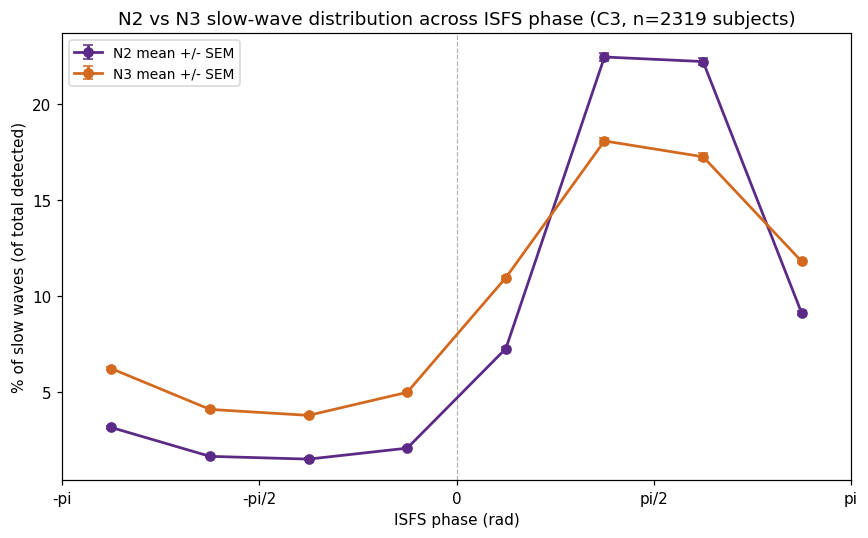

In [31]:
phase_mean = {state: stc.mean_sem(phase_rates[state]) for state in STATES}

fig, ax = plt.subplots(figsize=(8, 5))
for state in STATES:
    dark, light = COLORS[state]
    mean_r, sem_r = phase_mean[state]
    ax.errorbar(bin_centers, mean_r, yerr=sem_r, color=dark, marker="o", ms=6,
                capsize=3, lw=1.8, label=f"{state} mean +/- SEM")
ax.axvline(0, color="0.7", lw=0.8, ls="--")
ax.set(xlabel="ISFS phase (rad)", ylabel="% of slow waves (of total detected)",
       xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
       xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
       title=f"N2 vs N3 slow-wave distribution across ISFS phase ({CHANNEL}, n={len(SUBJECT_IDS)} subjects)")
ax.legend(frameon=True, fontsize=9)
fig.tight_layout()

## 6. Peak-Frequency Distribution

### 6.1 Distribution Plot

,mean,sd,median,iqr
N2,0.023062,0.009134,0.0225,0.0150
N3,0.026434,0.011931,0.0250,0.0175


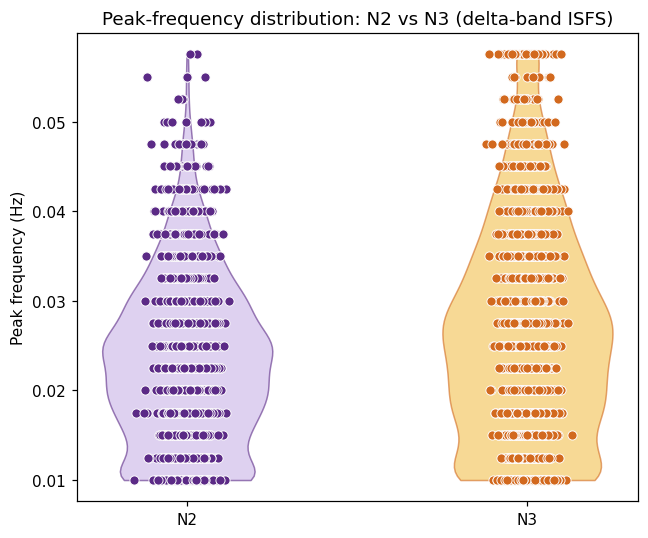

In [32]:
peak_freqs = {state: (n2_df if state == "N2" else n3_df)["peak_freq_hz"].to_numpy() for state in STATES}

fig, ax = plt.subplots(figsize=(6, 5))
positions = [1, 2]
parts = ax.violinplot([peak_freqs["N2"], peak_freqs["N3"]], positions=positions,
                       showmeans=False, showextrema=False)
for pc, state in zip(parts["bodies"], STATES):
    pc.set_facecolor(COLORS[state][1])
    pc.set_edgecolor(COLORS[state][0])
    pc.set_alpha(0.6)

rng = np.random.default_rng(0)
for pos, state in zip(positions, STATES):
    y = peak_freqs[state]
    x = rng.normal(pos, 0.04, size=y.size)
    ax.plot(x, y, "o", color=COLORS[state][0], ms=6, mec="white", mew=0.6, zorder=3)

ax.set(xticks=positions, xticklabels=STATES, ylabel="Peak frequency (Hz)",
       title="Peak-frequency distribution: N2 vs N3 (delta-band ISFS)")
fig.tight_layout()

peak_freq_summary = pd.DataFrame({state: stc.describe(peak_freqs[state]) for state in STATES}).T
peak_freq_summary

## 7. Statistical Comparison

### 7.1 Peak Frequency

In [33]:
peak_ttest = stc.paired_ttest(n2_df["peak_freq_hz"].to_numpy(), n3_df["peak_freq_hz"].to_numpy())
peak_dz = stc.paired_effect_size(n2_df["peak_freq_hz"].to_numpy(), n3_df["peak_freq_hz"].to_numpy())

print(f"n={peak_ttest['n_pairs']} | N2 {peak_ttest['x_mean']:.4f}+/-{peak_ttest['x_sd']:.4f} Hz | "
      f"N3 {peak_ttest['y_mean']:.4f}+/-{peak_ttest['y_sd']:.4f} Hz | "
      f"mean diff={peak_ttest['mean_diff']:.4f} Hz | t={peak_ttest['t_stat']:.3f} | "
      f"p={peak_ttest['p_value']:.4g} | Cohen's dz={peak_dz:.3f}")

n=2319 | N2 0.0231+/-0.0091 Hz | N3 0.0264+/-0.0119 Hz | mean diff=-0.0034 Hz | t=-12.018 | p=2.567e-32 | Cohen's dz=-0.250


### 7.2 Phase Bins

Paired t-test per ISFS phase bin (ordinary, on the bin-rate values -- not a circular test;
see the circular-preferred-phase supplement at the end of this section), BH-FDR corrected
across the 8 bins.

In [34]:
phase_bin_results = stc.compare_phase_bins(phase_rates["N2"], phase_rates["N3"], bin_centers)
phase_bin_results

,phase_bin,phase_center,N2_mean,N3_mean,mean_difference,n_pairs,t_stat,p_value,q_value,significant_FDR
0,1,-2.748894,3.134507,6.201021,-3.066515,2319,-36.579043,1.191113e-231,3.176300e-231,True
1,2,-1.963495,1.631169,4.076468,-2.445298,2319,-37.579894,8.960926e-242,3.584371e-241,True
2,3,-1.178097,1.487565,3.765850,-2.278285,2319,-35.214960,5.667993e-218,1.133599e-217,True
3,4,-0.392699,2.058359,4.967951,-2.909592,2319,-40.193942,1.670884e-268,1.336707e-267,True
4,5,0.392699,7.241706,10.935087,-3.693381,2319,-29.618767,8.740208e-164,1.398433e-163,True
5,6,1.178097,22.427024,18.055467,4.371557,2319,21.349269,1.796813e-92,2.053501e-92,True
6,7,1.963495,22.190003,17.231306,4.958697,2319,24.046541,2.946833e-114,3.929111e-114,True
7,8,2.748894,9.088083,11.781244,-2.693161,2319,-19.744648,2.474199e-80,2.474199e-80,True


### 7.3 Other ISFS Metrics

In [35]:
ISFS_METRICS = {
    "peak_freq_hz": "peak_frequency_hz",
    "peak_period_s": "peak_period_s",
    "bi_gaussian_amp": "amplitude",
    "bi_gaussian_sd_l": "sd_left",
    "bi_gaussian_sd_r": "sd_right",
    "bandwidth_hz": "bandwidth_hz",
    "auc": "auc",
    "chromatogram_peak_area": "chromatogram_peak_area",
}
isfs_metric_results = stc.compare_isfs_metrics(n2_df, n3_df, ISFS_METRICS)
isfs_metric_results

,Metric,N2 Mean,N2 SD,N3 Mean,N3 SD,Mean Difference,t,p,n_pairs,Cohen's dz,q
0,peak_frequency_hz,0.023062,0.009134,0.026434,0.011931,-0.003372,-12.017622,2.566502e-32,2319,-0.249556,6.844005e-32
1,peak_period_s,51.574814,22.960522,47.577039,24.447785,3.997774,6.418219,1.666605e-10,2319,0.133280,1.904691e-10
2,amplitude,9.149995,4.608516,7.081252,4.274370,2.068743,20.726086,1.111788e-87,2319,0.430395,8.894301e-87
3,sd_left,0.017341,0.013726,0.014493,0.013011,0.002848,7.602514,4.190546e-14,2319,0.157873,5.587395e-14
4,sd_right,0.021821,0.007851,0.020700,0.010703,0.001122,4.187563,2.925043e-05,2319,0.086958,2.925043e-05
5,bandwidth_hz,0.039162,0.016371,0.035192,0.017695,0.003970,8.342414,1.232761e-16,2319,0.173237,1.972418e-16
6,auc,0.298942,0.201775,0.209612,0.166180,0.089329,19.967466,5.586865e-82,2319,0.414641,2.234746e-81
7,chromatogram_peak_area,0.113081,0.083331,0.093327,0.072648,0.019755,9.686029,8.887263e-22,2319,0.201139,1.777453e-21


#### Supplemental: circular preferred-phase comparison

`mean_phase` (each subject/state's own circular mean of in-cycle event angles, already
computed by `infraslow.pipeline.phase.compute_subject_phase_features`) is a circular
quantity -- a linear paired t-test on raw `(-pi, pi]` angles is not meaningful. This reports
the cohort's circular mean/resultant length per state instead, as a supplement to Section
7.2's ordinary (non-circular) phase-bin-rate paired tests, not a replacement for them.

`circular_mean_and_resultant` drops NaN angles independently per call, so if `mean_phase`
had NaNs in different subjects between N2 and N3, the two circular means below could
silently be computed over different subject subsets -- breaking this project's "every
paired comparison must report n_pairs and preserve subject pairing" constraint. Section
2's selection filter already guarantees every one of the `SUBJECT_IDS` has a finite
`mean_phase` in both states, so both counts below are expected to equal `len(SUBJECT_IDS)`;
we print them explicitly anyway as defense-in-depth, so a reader can see the n directly
rather than trusting it implicitly.

In [36]:
n2_valid_phase = n2_df["mean_phase"].notna().sum()
n3_valid_phase = n3_df["mean_phase"].notna().sum()
print(f"Valid (non-NaN) mean_phase: N2 {n2_valid_phase}/{len(n2_df)} subjects, "
      f"N3 {n3_valid_phase}/{len(n3_df)} subjects")

n2_circ = stc.circular_mean_and_resultant(n2_df["mean_phase"].to_numpy())
n3_circ = stc.circular_mean_and_resultant(n3_df["mean_phase"].to_numpy())
print(f"N2 circular mean phase = {n2_circ[0]:.3f} rad, resultant length = {n2_circ[1]:.3f}")
print(f"N3 circular mean phase = {n3_circ[0]:.3f} rad, resultant length = {n3_circ[1]:.3f}")

Valid (non-NaN) mean_phase: N2 2319/2319 subjects, N3 2319/2319 subjects
N2 circular mean phase = 1.635 rad, resultant length = 0.965
N3 circular mean phase = 1.623 rad, resultant length = 0.882


## 8. Summary

In [37]:
n_sig_bins = int(phase_bin_results["significant_FDR"].sum())
n_sig_metrics = int((isfs_metric_results["q"] < 0.05).sum())

print("Summary")
print("=======")
print(f"Subjects: {len(SUBJECT_IDS)} (channel {CHANNEL}), paired N2/N3 usable slow-wave/delta data")
print(f"Peak frequency: N2 {peak_ttest['x_mean']:.4f} Hz vs N3 {peak_ttest['y_mean']:.4f} Hz, "
      f"t({peak_ttest['n_pairs'] - 1})={peak_ttest['t_stat']:.3f}, p={peak_ttest['p_value']:.4g}, "
      f"Cohen's dz={peak_dz:.3f}")
print(f"Phase bins significant after FDR (q<0.05): {n_sig_bins}/8")
print(f"ISFS metrics significant after FDR (q<0.05): {n_sig_metrics}/{len(isfs_metric_results)}")
print(f"N2 circular mean phase: {n2_circ[0]:.3f} rad (resultant {n2_circ[1]:.3f})")
print(f"N3 circular mean phase: {n3_circ[0]:.3f} rad (resultant {n3_circ[1]:.3f})")

Summary
Subjects: 2319 (channel C3), paired N2/N3 usable slow-wave/delta data
Peak frequency: N2 0.0231 Hz vs N3 0.0264 Hz, t(2318)=-12.018, p=2.567e-32, Cohen's dz=-0.250
Phase bins significant after FDR (q<0.05): 8/8
ISFS metrics significant after FDR (q<0.05): 8/8
N2 circular mean phase: 1.635 rad (resultant 0.965)
N3 circular mean phase: 1.623 rad (resultant 0.882)
